<a href="https://colab.research.google.com/github/Saransh-Basu-01/50-Ml-Projects-to-understand-LLMs/blob/main/Project_11_Network_graphs_of_cosine_similarities.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Part_1:Cosine Similarity Matrix

## Task_1:
- Import the BERT large model and its tokenizer. Extract the
embeddings matrix from the model.
Confirm that the text comprises 21 tokens with no repetitions.
Extract a submatrix of embeddings vectors for the tokens in
the sentence, then calculate the all-to-all cosine similarity using any
of the coding approaches you learned in previous projects.
Extract the non-redundant and non-trivial elements of the ma
trix, calculate a threshold as the median plus one standard deviation
(this threshold will be used when creating the graph), and show the
matrix and a histogram of the non-redundant values as in Figure 3.19.
As a reminder, the median of a dataset is the value that splits
the data into two equal-sized bins.

In [2]:
from transformers import BertTokenizer, BertModel

# load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-large-uncased')
model = BertModel.from_pretrained('bert-large-uncased')

embeddings = model.embeddings.word_embeddings.weight.detach().numpy()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.34GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-large-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
text = 'As Gregor Samsa awoke one morning from uneasy dreams he found himself transformed in his bed into a gigantic bug'
tokens=tokenizer.encode(text,add_special_tokens=False)
print(f'There are {len(tokens)} tokens in the text, {len(set(tokens))} of which are unique.\n')
for t in tokens:
  print(f'Token index {t:5} is "{tokenizer.decode(t)}"')

There are 21 tokens in the text, 21 of which are unique.

Token index  2004 is "as"
Token index 16973 is "gregor"
Token index  3520 is "sam"
Token index  3736 is "##sa"
Token index 19179 is "awoke"
Token index  2028 is "one"
Token index  2851 is "morning"
Token index  2013 is "from"
Token index 15491 is "uneasy"
Token index  5544 is "dreams"
Token index  2002 is "he"
Token index  2179 is "found"
Token index  2370 is "himself"
Token index  8590 is "transformed"
Token index  1999 is "in"
Token index  2010 is "his"
Token index  2793 is "bed"
Token index  2046 is "into"
Token index  1037 is "a"
Token index 20193 is "gigantic"
Token index 11829 is "bug"


In [20]:

E = embeddings[tokens,:]

# normalize each vector to its norm (unit length)
E_norm = E / np.linalg.norm(E,axis=1,keepdims=True)

# cosine similarity matrix
csM = E_norm @ E_norm.T

# get a vector of all unique matrix elements
uniqueCS = csM[np.nonzero(np.triu(csM,1))]

# here's the threshold!
thresh = np.median(uniqueCS) + np.std(uniqueCS)

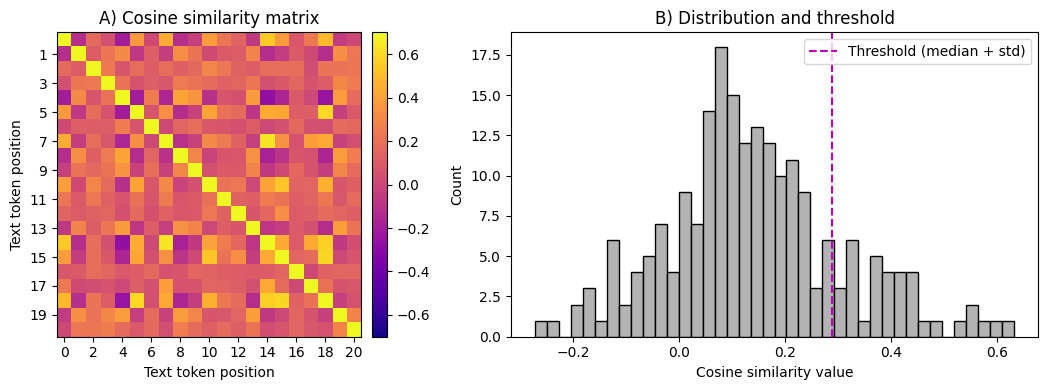

In [22]:
# visualize
fig,axs = plt.subplots(1,2,figsize=(12,4))

h = axs[0].imshow(csM,vmin=-.7,vmax=.7,cmap='plasma')
axs[0].set(xlabel='Text token position',ylabel='Text token position',
           xticks=range(0,len(tokens),2),yticks=range(1,len(tokens),2),
           title='A) Cosine similarity matrix')
fig.colorbar(h,ax=axs[0],fraction=.046,pad=.02)

axs[1].hist(uniqueCS,bins=40,color=[.7,.7,.7],edgecolor='k')
axs[1].axvline(thresh,linestyle='--',color='m',label='Threshold (median + std)')

axs[1].legend()
axs[1].set(xlabel='Cosine similarity value',ylabel='Count',title='B) Distribution and threshold')

plt.tight_layout()
plt.savefig('ch3_proj11_part1.png')
plt.show()

### Explanation

In [7]:
E.shape

(21, 1024)

In [8]:
E_E = embeddings[tokens]
E_E.shape


(21, 1024)

In [10]:
csM_h = [[1.0, 0.8, 0.3, 0.5, 0.2],
 [0.8, 1.0, 0.6, 0.4, 0.9],
 [0.3, 0.6, 1.0, 0.7, 0.1],
 [0.5, 0.4, 0.7, 1.0, 0.3],
 [0.2, 0.9, 0.1, 0.3, 1.0]]

In [13]:
np.triu(csM_h,1)

array([[0. , 0.8, 0.3, 0.5, 0.2],
       [0. , 0. , 0.6, 0.4, 0.9],
       [0. , 0. , 0. , 0.7, 0.1],
       [0. , 0. , 0. , 0. , 0.3],
       [0. , 0. , 0. , 0. , 0. ]])

In [14]:
np.nonzero(np.triu(csM_h,1))

(array([0, 0, 0, 0, 1, 1, 1, 2, 2, 3]), array([1, 2, 3, 4, 2, 3, 4, 3, 4, 4]))

- So np.nonzero(...) returns a tuple of two arrays:
- (row_indices, col_indices) =
- (array([0, 0, 0, 0, 1, 1, 1, 2, 2, 3]),
 array([1, 2, 3, 4, 2, 3, 4, 3, 4, 4]))

In [16]:
csM_h = np.array(csM_h)

In [17]:
csM_h[np.nonzero(np.triu(csM_h,1))]

array([0.8, 0.3, 0.5, 0.2, 0.6, 0.4, 0.9, 0.7, 0.1, 0.3])

# Part_2:The Network Similarity Graph

## task_1:
- Read the descriptions below and translate them into code. The result
should be Figure 3.18.

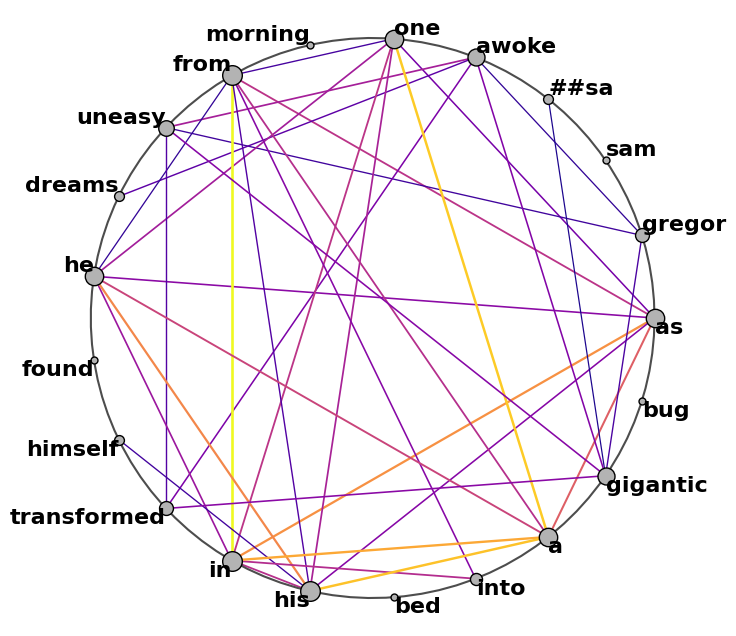

In [23]:
# values for theta
N = len(tokens)
th = np.linspace(0,2*np.pi-2*np.pi/N,N)

maxcs = np.sort(csM[csM<.99])[-1]

# create a figure
plt.figure(figsize=(8,8))

thHighres = np.linspace(0,2*np.pi,100)
plt.plot(np.cos(thHighres),np.sin(thHighres),color=[.3,.3,.3])

# loop over tokens
for i in range(N):

  # determine dot (marker) size
  dotsize = 5 * np.sqrt((csM[i]>thresh).sum())

  # plot the dot
  plt.plot(np.cos(th[i]),np.sin(th[i]),'ko',markerfacecolor=[.7,.7,.7],markersize=dotsize)

  # draw text at the tokens
  plt.text(np.cos(th[i]),np.sin(th[i]),tokenizer.decode([tokens[i]]),
           ha=['right','left'][int(np.cos(th[i])>0)], # pick a side based on cosine sign
           va=['top','bottom'][int(np.sin(th[i])>0)], # pick a vertical orientation from sine
           fontweight='bold',fontsize=16)

  # loop over all the other tokens
  for j in range(i+1,N):

    # only draw a line if similarity exceeds the threshold
    if csM[i,j]>thresh:

      # color corresponding to cossim strength
      cidx = (csM[i,j]-thresh) / (maxcs-thresh)
      color = plt.cm.plasma(cidx)

      # draw it!
      x_vals = [ np.cos(th[i]),np.cos(th[j]) ]
      y_vals = [ np.sin(th[i]),np.sin(th[j]) ]
      plt.plot(x_vals,y_vals,zorder=-10,color=color,linewidth=3*csM[i,j])

plt.axis('off')
plt.show()

# Part_3:Graphing Number Networks

## Task_1:
- Calculate the all-to-all cosine similarity matrix. You can copy your
code from Project 10, or rewrite it for an additional challenge.
Write code that creates the graph in Figure 3.20. There is no
threshold and the node marker sizes are all the same, but the procedure is otherwise the same as I described in Part 2.